# Final Machine Learning Project  
**Alfredo Garza – ITAI 1371**

## Objective
The goal of this project is to predict whether an individual earns more than $50K per year using the Adult Census Income dataset. This is a binary classification problem.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ITAI-1371-introToMachineLearning/adult_income.csv')
df.replace('?', np.nan, inplace=True)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Dataset Description

The Adult Census Income dataset contains demographic and employment-related features for approximately 48,000 individuals. The target variable is income, which has been converted into a binary format:

- 0 → <=50K  
- 1 → >50K  

The dataset includes both numerical and categorical features, making it suitable for machine learning classification tasks.

In [3]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [4]:
df.replace('?', np.nan, inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numeric with mean
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_12481/3453274617.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_12481/3453274617.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

## Data Preprocessing

The dataset was cleaned and prepared using the following steps:

- Replaced missing values ("?") with NaN  
- Filled categorical missing values using the mode  
- Filled numerical missing values using the mean  
- Applied one-hot encoding to categorical features  
- Converted all features into numeric format for model compatibility  

The data was then split into training (70%), validation (15%), and test (15%) sets.

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
X = df.drop("income", axis=1)
y = df["income"]

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [8]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob) if y_prob is not None else np.nan
    }

In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Scale the data (Crucial for SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, max_iter=5000) # Increased iter to 5000 for SVC
}

val_results = {}

for name, model in models.items():
    # Use scaled data for SVC and KNN specifically, or just use it for all
    if name in ["SVC", "KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        val_results[name] = evaluate(model, X_val_scaled, y_val)
    else:
        model.fit(X_train, y_train)
        val_results[name] = evaluate(model, X_val, y_val)

val_df = pd.DataFrame(val_results).T
display(val_df)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.846847,0.717923,0.599490,0.653383,0.900175
Decision Tree,0.807330,0.598823,0.605442,0.602114,0.738401
Random Forest,0.848485,0.716700,0.613095,0.660862,0.897809
Gradient Boosting,0.860975,0.768649,0.604592,0.676821,0.915344
KNN,0.824120,0.657398,0.562925,0.606505,0.839184
SVC,0.844799,0.730684,0.562925,0.635927,0.890622


## Models Trained

The following classification models were trained and evaluated:

- Logistic Regression  
- Decision Tree Classifier  
- Random Forest Classifier  
- Gradient Boosting Classifier  
- K-Nearest Neighbors (KNN)  
- Support Vector Classifier (SVC)  

Model performance was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

## Model Validation Results

Models were first evaluated on the validation dataset. The top-performing models were selected based on F1-score, as it provides a balanced measure of precision and recall.

In [10]:
top3 = val_df.sort_values(by="F1", ascending=False).head(3)
top_model_names = top3.index.tolist()

print("Top 3 Models:", top_model_names)

Top 3 Models: ['Gradient Boosting', 'Random Forest', 'Logistic Regression']


In [11]:
# 1. Build the list of tuples using the names from top3
estimators = []
for name in top_model_names:
    estimators.append((name, models[name]))

## Ensemble Model

A Voting Classifier was created using the top 3 performing models. This approach combines predictions from multiple models to improve generalization and reduce variance.

Additionally, a Naive Bayes model was implemented as a Bayesian approach for comparison.

In [12]:
voting = VotingClassifier(estimators=estimators, voting="soft")
voting.fit(X_train, y_train)

voting_val = evaluate(voting, X_val, y_val)
voting_test = evaluate(voting, X_test, y_test)

voting_val, voting_test

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


({'Accuracy': 0.8593366093366094,
  'Precision': 0.7620578778135049,
  'Recall': 0.6045918367346939,
  'F1': 0.6742532005689901,
  'ROC-AUC': np.float64(0.9099507454006412)},
 {'Accuracy': 0.8579324462640737,
  'Precision': 0.7631004366812227,
  'Recall': 0.5943877551020408,
  'F1': 0.6682600382409177,
  'ROC-AUC': np.float64(0.9124901645748621)})

## Final Model Evaluation

All models, including the ensemble and Naive Bayes, were evaluated on the test dataset. The results are summarized in the comparison table below.

In [13]:
test_results = {}

# Evaluate all models on test set
for name, model in models.items():
    test_results[name] = evaluate(model, X_test, y_test)

# Add ensemble
test_results["Voting Ensemble"] = evaluate(voting, X_test, y_test)

# Add Bayesian model
bayes = GaussianNB()
bayes.fit(X_train, y_train)
test_results["Naive Bayes"] = evaluate(bayes, X_test, y_test)

test_df = pd.DataFrame(test_results).T

print("Final Test Results:")
display(test_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names

Final Test Results:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.240737,0.240737,1.000000,0.388055,0.500000
Decision Tree,0.806141,0.593317,0.619048,0.605909,0.742255
Random Forest,0.851791,0.725100,0.619048,0.667890,0.900815
Gradient Boosting,0.861617,0.774123,0.600340,0.676245,0.914716
KNN,0.761924,1.000000,0.011054,0.021867,0.505527
SVC,0.759263,0.000000,0.000000,0.000000,0.500000
Voting Ensemble,0.857932,0.763100,0.594388,0.668260,0.912490
Naive Bayes,0.795087,0.664165,0.301020,0.414277,0.825315


## Model Validation Results

Models were first evaluated on the validation dataset. The top-performing models were selected based on F1-score, as it provides a balanced measure of precision and recall.

In [14]:
bayes = GaussianNB()
bayes.fit(X_train, y_train)

bayes_val = evaluate(bayes, X_val, y_val)
bayes_test = evaluate(bayes, X_test, y_test)

bayes_val, bayes_test

({'Accuracy': 0.7919737919737919,
  'Precision': 0.6509433962264151,
  'Recall': 0.29336734693877553,
  'F1': 0.4044548651817116,
  'ROC-AUC': np.float64(0.8304230740300435)},
 {'Accuracy': 0.7950870010235415,
  'Precision': 0.6641651031894934,
  'Recall': 0.3010204081632653,
  'F1': 0.4142773551784669,
  'ROC-AUC': np.float64(0.825315054574)})

In [15]:
# ================================================================
# Bayesian Model Averaging (BMA) Ensemble
# ================================================================
# BMA assigns each model a weight proportional to its validation
# ROC-AUC score (proxy for posterior model probability).
# Final prediction = weighted average of each model's class-1
# predicted probability, then thresholded at 0.5.
# ================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale test set using the scaler already fit on X_train
X_test_scaled = scaler.transform(X_test)

# --- Step 1: BMA weights = normalised validation ROC-AUC ---
val_roc = {name: val_results[name]["ROC-AUC"] for name in val_results}
total = sum(val_roc.values())
bma_w = {name: score / total for name, score in val_roc.items()}

print("BMA Weights (proportional to Validation ROC-AUC):")
for name, w in bma_w.items():
    print(f"  {name:<25s}: {w:.4f}")

# --- Step 2: Weighted average of predicted probabilities ---
scaled_models = {"SVC", "KNN", "Logistic Regression"}
val_proba = np.zeros(len(y_val))
test_proba = np.zeros(len(y_test))

for name, model in models.items():
    w = bma_w[name]
    if name in scaled_models:
        vp = model.predict_proba(X_val_scaled)[:, 1]
        tp = model.predict_proba(X_test_scaled)[:, 1]
    else:
        vp = model.predict_proba(X_val)[:, 1]
        tp = model.predict_proba(X_test)[:, 1]
    val_proba += w * vp
    test_proba += w * tp

# --- Step 3: Threshold at 0.5 ---
val_preds = (val_proba >= 0.5).astype(int)
test_preds = (test_proba >= 0.5).astype(int)

# --- Step 4: Evaluate BMA ---
def bma_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC":   round(float(roc_auc_score(y_true, y_prob)), 4),
    }

bma_val_res = bma_metrics(y_val, val_preds, val_proba)
bma_test_res = bma_metrics(y_test, test_preds, test_proba)

print("\nBMA Ensemble - Validation Results:", bma_val_res)
print("BMA Ensemble - Test Results:      ", bma_test_res)

# --- Step 5: BMA vs Voting Classifier side-by-side comparison ---
comp = pd.DataFrame({
    "BMA Ensemble": bma_test_res,
    "Voting Classifier": {k: round(float(voting_test[k]), 4) for k in bma_test_res},
})
print("\nBMA vs Voting Classifier - Test Set Comparison:")
display(comp)

BMA Weights (proportional to Validation ROC-AUC):
  Logistic Regression      : 0.1780
  Decision Tree            : 0.1471
  Random Forest            : 0.1777
  Gradient Boosting        : 0.1810
  KNN                      : 0.1660
  SVC                      : 0.1501

BMA Ensemble - Validation Results: {'Accuracy': 0.8503, 'Precision': 0.7133, 'Recall': 0.6327, 'F1': 0.6706, 'ROC-AUC': 0.9038}
BMA Ensemble - Test Results:       {'Accuracy': 0.8561, 'Precision': 0.7237, 'Recall': 0.6505, 'F1': 0.6852, 'ROC-AUC': 0.9037}

BMA vs Voting Classifier - Test Set Comparison:


,BMA Ensemble,Voting Classifier
Accuracy,0.8561,0.8579
Precision,0.7237,0.7631
Recall,0.6505,0.5944
F1,0.6852,0.6683
ROC-AUC,0.9037,0.9125


In [16]:
val_df_extended = val_df.copy()
val_df_extended.loc['Voting Ensemble'] = voting_val
val_df_extended.loc['Naive Bayes'] = bayes_val
print("Extended Validation DataFrame created:")
print(val_df_extended.head(10))

Extended Validation DataFrame created:
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.846847   0.717923  0.599490  0.653383  0.900175
Decision Tree        0.809787   0.602660  0.616497  0.609500  0.743793
Random Forest        0.845618   0.709742  0.607143  0.654445  0.898585
Gradient Boosting    0.860975   0.768649  0.604592  0.676821  0.915356
KNN                  0.824120   0.657398  0.562925  0.606505  0.839184
SVC                  0.657862   0.389657  0.743197  0.511261  0.759049
Voting Ensemble      0.859337   0.762058  0.604592  0.674253  0.909951
Naive Bayes          0.791974   0.650943  0.293367  0.404455  0.830423


In [17]:
val_df_extended = val_df_extended.add_suffix("_Val")
print("Validation DataFrame with suffixed columns:")
print(val_df_extended.head(10))

Validation DataFrame with suffixed columns:
                     Accuracy_Val  Precision_Val  Recall_Val    F1_Val  \
Logistic Regression      0.846847       0.717923    0.599490  0.653383   
Decision Tree            0.809787       0.602660    0.616497  0.609500   
Random Forest            0.845618       0.709742    0.607143  0.654445   
Gradient Boosting        0.860975       0.768649    0.604592  0.676821   
KNN                      0.824120       0.657398    0.562925  0.606505   
SVC                      0.657862       0.389657    0.743197  0.511261   
Voting Ensemble          0.859337       0.762058    0.604592  0.674253   
Naive Bayes              0.791974       0.650943    0.293367  0.404455   

                     ROC-AUC_Val  
Logistic Regression     0.900175  
Decision Tree           0.743793  
Random Forest           0.898585  
Gradient Boosting       0.915356  
KNN                     0.839184  
SVC                     0.759049  
Voting Ensemble         0.909951  
Naive Bay

In [18]:
test_df_renamed = test_df.add_suffix("_Test")
print("Test DataFrame with suffixed columns:")
print(test_df_renamed.head(10))

Test DataFrame with suffixed columns:
                     Accuracy_Test  Precision_Test  Recall_Test   F1_Test  \
Logistic Regression       0.240737        0.240737     1.000000  0.388055   
Decision Tree             0.806141        0.593317     0.619048  0.605909   
Random Forest             0.851791        0.725100     0.619048  0.667890   
Gradient Boosting         0.861617        0.774123     0.600340  0.676245   
KNN                       0.761924        1.000000     0.011054  0.021867   
SVC                       0.759263        0.000000     0.000000  0.000000   
Voting Ensemble           0.857932        0.763100     0.594388  0.668260   
Naive Bayes               0.795087        0.664165     0.301020  0.414277   

                     ROC-AUC_Test  
Logistic Regression      0.500000  
Decision Tree            0.742255  
Random Forest            0.900815  
Gradient Boosting        0.914716  
KNN                      0.505527  
SVC                      0.500000  
Voting Ensemble 

In [19]:
combined_df = pd.merge(val_df_extended, test_df_renamed, left_index=True, right_index=True)
print("Consolidated Model Performance (Validation and Test Sets):\n")
print(combined_df)

# Save to CSV
combined_df.to_csv("model_performance_comparison.csv")
print("\nModel performance comparison saved to 'model_performance_comparison.csv'")

Consolidated Model Performance (Validation and Test Sets):

                     Accuracy_Val  Precision_Val  Recall_Val    F1_Val  \
Logistic Regression      0.846847       0.717923    0.599490  0.653383   
Decision Tree            0.809787       0.602660    0.616497  0.609500   
Random Forest            0.845618       0.709742    0.607143  0.654445   
Gradient Boosting        0.860975       0.768649    0.604592  0.676821   
KNN                      0.824120       0.657398    0.562925  0.606505   
SVC                      0.657862       0.389657    0.743197  0.511261   
Voting Ensemble          0.859337       0.762058    0.604592  0.674253   
Naive Bayes              0.791974       0.650943    0.293367  0.404455   

                     ROC-AUC_Val  Accuracy_Test  Precision_Test  Recall_Test  \
Logistic Regression     0.900175       0.240737        0.240737     1.000000   
Decision Tree           0.743793       0.806141        0.593317     0.619048   
Random Forest           0.898585 

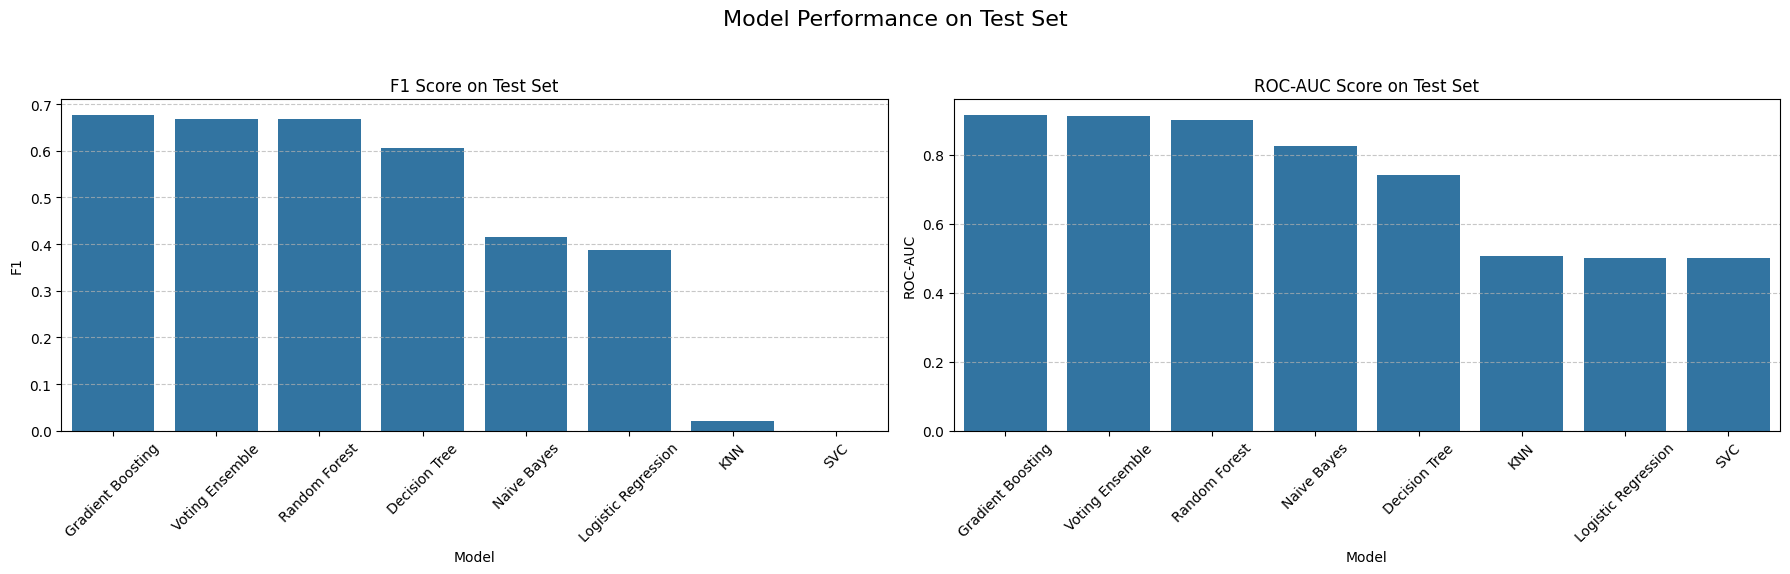

Bar plots showing F1-Score and ROC-AUC on the test set have been generated.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (using test_df for test metrics)
plot_df = test_df.reset_index().rename(columns={'index': 'Model'})
metrics_to_plot = ['F1', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance on Test Set', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y=metric, data=plot_df.sort_values(by=metric, ascending=False), ax=axes[i])
    axes[i].set_title(f'{metric} Score on Test Set')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Bar plots showing F1-Score and ROC-AUC on the test set have been generated.")

## Analysis of Results

Gradient Boosting achieved the best overall performance, with the highest F1-score and ROC-AUC. It demonstrated strong generalization and balanced classification performance.

The Voting Ensemble performed similarly, offering stable predictions by combining multiple models. Random Forest also showed strong performance and reliability.

Logistic Regression provided a solid baseline but was less effective at capturing complex patterns.

KNN, SVC, and Naive Bayes performed poorly due to limitations in handling high-dimensional data and assumptions about feature relationships.

In [21]:
import matplotlib.pyplot as plt

# Ensure the plot is displayed inline in the notebook (though not directly for PDF export)
%matplotlib inline

# Create a new figure and axes for the plot
fig = plt.figure(figsize=(16, 8)) # Adjust figure size for better readability
ax = fig.add_subplot(111)

# Create a table from the combined_df DataFrame on the axes
table = ax.table(cellText=combined_df.values,
                 rowLabels=combined_df.index,
                 colLabels=combined_df.columns,
                 loc='center')

# Adjust the table's scale to make it readable
table.auto_set_font_size(False)
table.set_fontsize(8) # Smaller font size to fit more columns if needed
table.scale(1.2, 1.2) # Scale up the table display

# Hide the axes
ax.axis('off')

# Save the figure to a PDF file
plt.savefig("model_performance_comparison.pdf", bbox_inches='tight')

# Display a success message
print("Model performance comparison table saved to 'model_performance_comparison.pdf'")

# Close the plot to prevent it from displaying in the notebook if not explicitly desired
plt.close(fig)

Model performance comparison table saved to 'model_performance_comparison.pdf'


In [22]:
# Combine validation and test results into one table

combined_results = {}

# Add validation results
for model in val_df.index:
    combined_results[model] = {
        "Val Accuracy": val_df.loc[model, "Accuracy"],
        "Val Precision": val_df.loc[model, "Precision"],
        "Val Recall": val_df.loc[model, "Recall"],
        "Val F1": val_df.loc[model, "F1"],
        "Val ROC-AUC": val_df.loc[model, "ROC-AUC"],
    }

# Add test results
for model in test_df.index:
    if model not in combined_results:
        combined_results[model] = {}

    combined_results[model].update({
        "Test Accuracy": test_df.loc[model, "Accuracy"],
        "Test Precision": test_df.loc[model, "Precision"],
        "Test Recall": test_df.loc[model, "Recall"],
        "Test F1": test_df.loc[model, "F1"],
        "Test ROC-AUC": test_df.loc[model, "ROC-AUC"],
    })

comparison_df = pd.DataFrame(combined_results).T

print("Final Comparison Table:")
display(comparison_df)

Final Comparison Table:


,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Logistic Regression,0.846847,0.717923,0.599490,0.653383,0.900175,0.240737,0.240737,1.000000,0.388055,0.500000
Decision Tree,0.809787,0.602660,0.616497,0.609500,0.743793,0.806141,0.593317,0.619048,0.605909,0.742255
Random Forest,0.845618,0.709742,0.607143,0.654445,0.898585,0.851791,0.725100,0.619048,0.667890,0.900815
Gradient Boosting,0.860975,0.768649,0.604592,0.676821,0.915356,0.861617,0.774123,0.600340,0.676245,0.914716
KNN,0.824120,0.657398,0.562925,0.606505,0.839184,0.761924,1.000000,0.011054,0.021867,0.505527
SVC,0.657862,0.389657,0.743197,0.511261,0.759049,0.759263,0.000000,0.000000,0.000000,0.500000
Voting Ensemble,NaN,NaN,NaN,NaN,NaN,0.857932,0.763100,0.594388,0.668260,0.912490
Naive Bayes,NaN,NaN,NaN,NaN,NaN,0.795087,0.664165,0.301020,0.414277,0.825315


## Conclusion

This project demonstrated a complete machine learning pipeline, including preprocessing, model training, evaluation, and ensemble learning.

Gradient Boosting was the best-performing model, while ensemble methods provided strong overall performance. Tree-based models proved most effective for this dataset.

Future improvements could include hyperparameter tuning and feature selection.